Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

[INFO] Loading dataset from: /content/drive/MyDrive/CMSC498E/human_tips_dataset.npy
[INFO] Using Device: cuda
[INFO] Dataset Splits -> Train: 17576 | Val: 2197 | Test: 2198

[INFO] Starting Optimization with Early Stopping...
Epoch [  1/150] | Train: 0.181157 | Val: 0.078311 | ⭐ Best!
Epoch [  2/150] | Train: 0.071636 | Val: 0.070036 | ⭐ Best!
Epoch [  3/150] | Train: 0.069715 | Val: 0.069526 | ⭐ Best!
Epoch [  4/150] | Train: 0.069395 | Val: 0.069345 | ⭐ Best!
Epoch [  5/150] | Train: 0.069273 | Val: 0.069260 | ⭐ Best!
Epoch [  6/150] | Train: 0.069209 | Val: 0.069216 | ⭐ Best!
Epoch [  7/150] | Train: 0.069177 | Val: 0.069193 | ⭐ Best!
Epoch [  8/150] | Train: 0.069160 | Val: 0.069178 | ⭐ Best!
Epoch [  9/150] | Train: 0.069149 | Val: 0.069170 | ⭐ Best!
Epoch [ 10/150] | Train: 0.069141 | Val: 0.069164 | ⭐ Best!
Epoch [ 11/150] | Train: 0.069139 | Val: 0.0

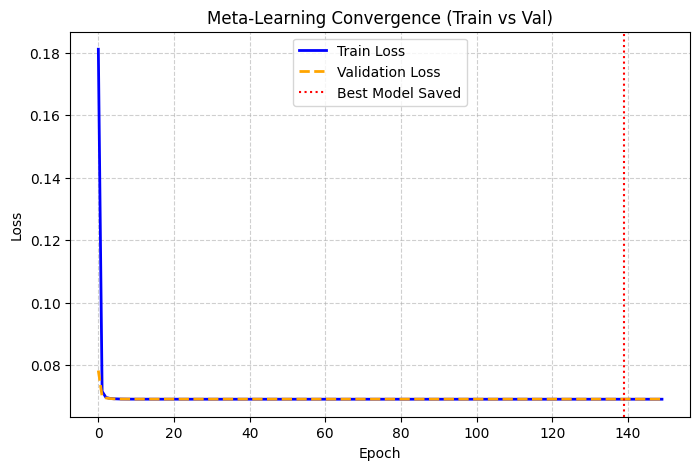

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import os
import copy
from google.colab import drive
from torch.utils.data import TensorDataset, DataLoader, random_split

# ============================================================================
# Step 1: Mount Google Drive & Load Dataset
# ============================================================================
drive.mount('/content/drive')
DATA_PATH = "/content/drive/MyDrive/CMSC498E/human_tips_dataset.npy"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Dataset not found at {DATA_PATH}. Please check the path.")

print(f"\n[INFO] Loading dataset from: {DATA_PATH}")
dataset_np = np.load(DATA_PATH) # Shape: (Total_Frames, 5, 3)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Using Device: {device}")

human_tips_tensor = torch.tensor(dataset_np, dtype=torch.float32).to(device)
full_dataset = TensorDataset(human_tips_tensor)

# ============================================================================
# Step 2: Train / Validation / Test Split (80% / 10% / 10%)
# ============================================================================
total_size = len(full_dataset)
train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

batch_size = 256
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"[INFO] Dataset Splits -> Train: {train_size} | Val: {val_size} | Test: {test_size}")

# ============================================================================
# Step 3: Define the Topology Mapping Network & Loss Function
# ============================================================================
class TopologyMappingNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(15, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 4 * 5)
        )

    def forward(self, p_human):
        b_size = p_human.shape[0]
        x = p_human.view(b_size, -1)
        M_raw = self.mlp(x).view(b_size, 4, 5)
        M = torch.softmax(M_raw, dim=-1)
        p_target = torch.bmm(M, p_human)
        return p_target, M

model = TopologyMappingNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Physics & URDF Constants
ROBOT_HAND_LENGTH = 0.1482
MAX_REACH = 0.150
W_SHAPE = 1.0
W_BOUNDS = 10.0
W_DIVERSITY = 1.0 # Orthogonality Penalty Weight
W_PRIOR = 1.0

def compute_physics_loss(p_h, p_t, M):
    b_size = M.shape[0]

    # 1. Bounds Loss
    distances_from_wrist = torch.norm(p_t, dim=-1)
    violation = torch.relu(distances_from_wrist - MAX_REACH)
    loss_bounds = torch.mean(violation ** 2)

    # 2. Shape Consistency Loss
    human_hand_length = torch.max(torch.norm(p_h, dim=-1), dim=1, keepdim=True).values
    dynamic_scale = ROBOT_HAND_LENGTH / (human_hand_length + 1e-6)

    centroid_h = torch.mean(p_h, dim=1, keepdim=True)
    centroid_t = torch.mean(p_t, dim=1, keepdim=True)

    spread_h = torch.mean(torch.norm(p_h - centroid_h, dim=-1), dim=1, keepdim=True)
    spread_t = torch.mean(torch.norm(p_t - centroid_t, dim=-1), dim=1, keepdim=True)

    target_spread = spread_h * dynamic_scale
    loss_shape = torch.mean((spread_t - target_spread) ** 2)

    # 3. Diversity Loss
    M_bmm = torch.bmm(M, M.transpose(1, 2))
    identity = torch.eye(4, device=M.device).unsqueeze(0).expand(b_size, 4, 4)
    loss_diversity = torch.mean((M_bmm - identity) ** 2)

    M_anchor = torch.tensor([
        [0.5, 0.5, 0.0, 0.0, 0.0],
        [0.0, 0.5, 0.5, 0.0, 0.0],
        [0.0, 0.0, 0.5, 0.5, 0.0],
        [0.0, 0.0, 0.0, 0.5, 0.5]
    ], device=M.device).unsqueeze(0).expand(b_size, 4, 5)

    loss_prior = torch.mean((M - M_anchor) ** 2)
    total_loss = (W_SHAPE * loss_shape) + (W_BOUNDS * loss_bounds) + \
                 (W_DIVERSITY * loss_diversity) + (W_PRIOR * loss_prior)

    return total_loss, loss_shape, loss_bounds, loss_diversity

# ============================================================================
# Step 4: Training Loop with EARLY STOPPING
# ============================================================================
max_epochs = 150
patience = 10
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_wts = copy.deepcopy(model.state_dict())

history = {'train_loss': [], 'val_loss': []}

print("\n[INFO] Starting Optimization with Early Stopping...")

for epoch in range(max_epochs):
    # --------- TRAINING PHASE ---------
    model.train()
    train_loss = 0.0
    for batch in train_loader:
        p_h = batch[0]
        optimizer.zero_grad()

        p_t, M = model(p_h)
        loss, _, _, _ = compute_physics_loss(p_h, p_t, M)

        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # --------- VALIDATION PHASE ---------
    model.eval()
    val_loss = 0.0
    with torch.no_grad(): # No gradients needed during validation!
        for batch in val_loader:
            p_h = batch[0]
            p_t, M = model(p_h)
            loss, _, _, _ = compute_physics_loss(p_h, p_t, M)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)

    # Store history
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)

    # --------- EARLY STOPPING LOGIC ---------
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
        status = "⭐ Best!"
    else:
        epochs_no_improve += 1
        status = f"Patience: {epochs_no_improve}/{patience}"

    if (epoch + 1) % 5 == 0 or epochs_no_improve == 0:
        print(f"Epoch [{epoch+1:3d}/{max_epochs}] | Train: {avg_train_loss:.6f} | Val: {avg_val_loss:.6f} | {status}")

    if epochs_no_improve >= patience:
        print(f"\n[🛑 EARLY STOPPING] Triggered at epoch {epoch+1}. Restoring best weights.")
        break

# Restore best weights
model.load_state_dict(best_model_wts)

# ============================================================================
# Step 5: Test Evaluation & Display Final Matrix
# ============================================================================
print("\n[INFO] Evaluating on Unseen Test Dataset...")
model.eval()
test_loss = 0.0
with torch.no_grad():
    for batch in test_loader:
        p_h = batch[0]
        p_t, M = model(p_h)
        loss, _, _, _ = compute_physics_loss(p_h, p_t, M)
        test_loss += loss.item()

avg_test_loss = test_loss / len(test_loader)
print(f"🚀 Final Test Loss: {avg_test_loss:.6f}")

# Extract and display the matrix using a sample from the TEST set
with torch.no_grad():
    sample_human = next(iter(test_loader))[0][0:1]
    _, learned_M = model(sample_human)

    print("\n" + "="*50)
    print(" 🧠 BEST TOPOLOGY MAPPING MATRIX (M) ")
    print("="*50)
    print("Rows: Robot Fingers (Index, Middle, Ring, Thumb)")
    print("Cols: Human Fingers (Thumb, Index, Middle, Ring, Pinky)")
    print("-" * 50)
    M_np = learned_M.cpu().numpy()[0]
    np.set_printoptions(precision=3, suppress=True)
    print(M_np)
    print("="*50 + "\n")

# Plot Train vs Val Loss
plt.figure(figsize=(8, 5))
plt.plot(history['train_loss'], label='Train Loss', color='blue', linewidth=2)
plt.plot(history['val_loss'], label='Validation Loss', color='orange', linewidth=2, linestyle='--')
plt.axvline(x=len(history['train_loss']) - patience - 1, color='red', linestyle=':', label='Best Model Saved')
plt.title('Meta-Learning Convergence (Train vs Val)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()